### Multi Agent Supervisor with RAG

Supervisor is a multi-agent architecture where specialized agents are co-ordinated by a central supervisor agent. The supervisor agent controls all communication flow and task delegation, making decisions about which agent to invoke based on the current context and task requirements.

A supervisor system with two agents - a research and a math expert. By the end of the tutorial:

1. Build specialized research and math agents
2. Build a supervisor for orchestrating them with the prebuilt langgraph-supervisor
3. Build a supervisor
4. Implement advanced task delegation

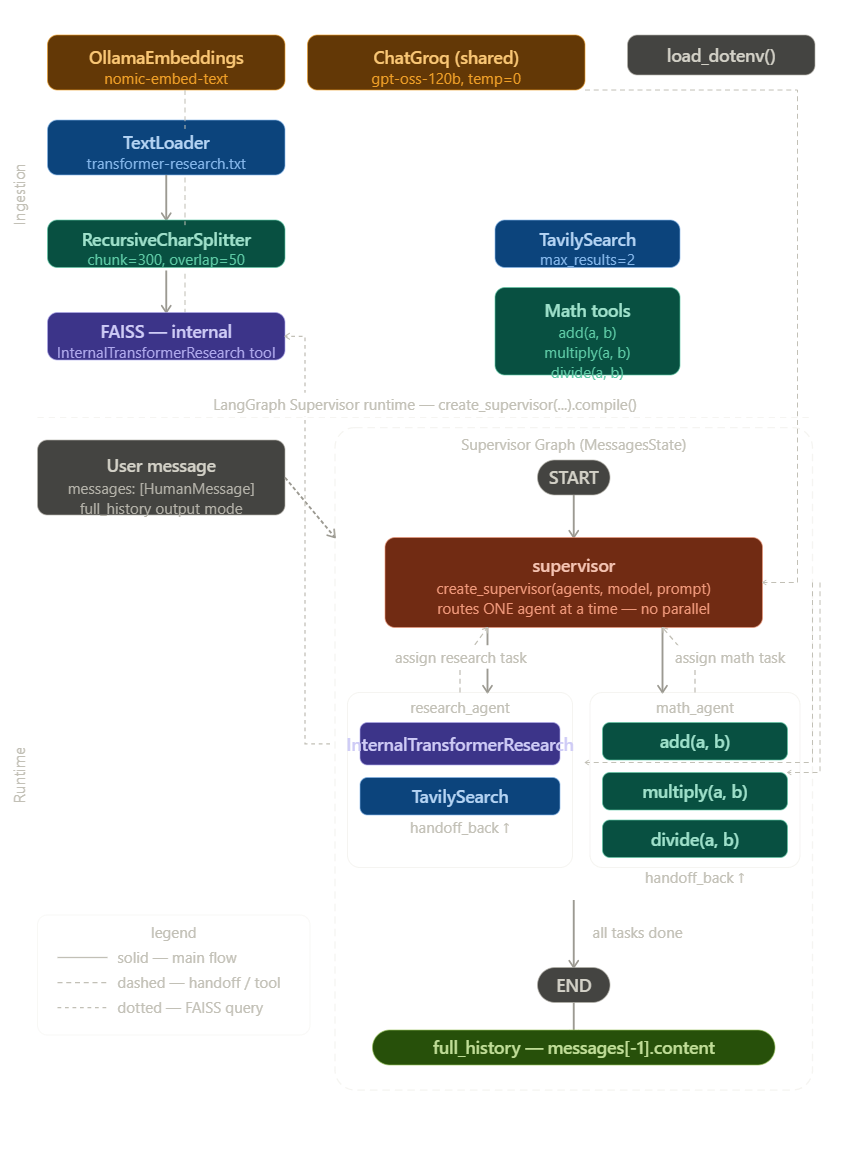

In [1]:
# ------------------------------------------------------------
# 1. LLM and Embeddings 
# ------------------------------------------------------------

from langchain_groq import ChatGroq
from langchain_ollama.embeddings import OllamaEmbeddings
import os
from dotenv import load_dotenv

load_dotenv()
os.environ['GROQ_API_KEY'] = os.getenv('groq_api_key')
os.environ['TAVILY_API_KEY'] = os.getenv('tavily_api_key')

llm = ChatGroq(model='openai/gpt-oss-120b', max_tokens=1000, temperature=0)
embedding = OllamaEmbeddings(model='nomic-embed-text')

In [2]:
# ------------------------------------------------------------
# 2. Retriever - Text File and Tools
# ------------------------------------------------------------

from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_classic.agents import Tool

# Text File
def make_retriever_tool_from_text(file, name, desc):
    docs = TextLoader(file_path=file, encoding='utf-8').load()
    chunks = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=50).split_documents(docs)
    vector_db = FAISS.from_documents(chunks, embedding)
    retriever = vector_db.as_retriever()
    
    def tool_func(query: str) -> str:
        print(f'🔨 Using Tool: {name}')
        results = retriever.invoke(query)
        return '\n\n'.join(doc.page_content[:300] for doc in results[:3])
    return Tool(name=name, description=desc, func=tool_func)

internal_tool_text = make_retriever_tool_from_text(
    'data/transformer-research.txt',
    'InternalTransformerResearch',
    'Searching transformer research notes for experimental results'
)

from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=2)

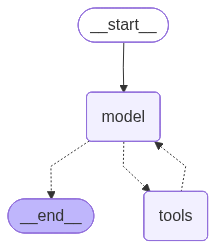

In [3]:
# ------------------------------------------------------------
# 3. Create Agent - Researcher
# ------------------------------------------------------------

from langchain.agents import create_agent

research_agent = create_agent(
    model=llm,
    tools=[internal_tool_text, tavily_tool],
    system_prompt=(
        "You are a research agent. \n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with research-related tasks, DO NOT do any math\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name='research_agent'
)

research_agent

In [4]:
# ------------------------------------------------------------
# 4. Create Agent - Math
# ------------------------------------------------------------

def add(a: float, b: float):
    """Add two numbers."""
    return a + b

def multiply(a: float, b: float):
    """Multiple two numbers."""
    return a * b

def divide(a: float, b: float):
    """Divide two numbers."""
    return a / b

math_agent = create_agent(
    model=llm,
    tools=[add, multiply, divide],
    system_prompt=(
        "You are a math agent. \n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with math-related tasks\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name='math_agent'
)

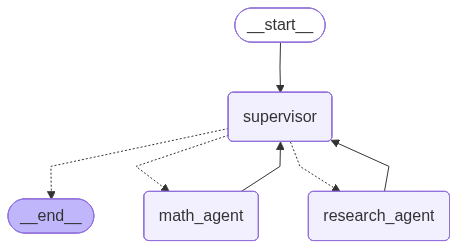

In [5]:
# ------------------------------------------------------------
# 5. Create Supervisor Agent
# ------------------------------------------------------------

from langgraph_supervisor import create_supervisor

supervisor = create_supervisor(
    agents=[research_agent, math_agent],
    model=llm,
    prompt=(
        "You are a supervisor managing two agents: \n"
        "- a research agent. Assign research-related tasks to this agent\n"
        "- a math agent. Assign math-related task to this agent\n"
        "Assign work to one agent at a time, do not call agents in parallel.\n"
        "Do not do any work yourself."
    ),
    add_handoff_back_messages=True,
    output_mode='full_history'
).compile()

supervisor

In [6]:
response = supervisor.invoke(
    {
        'messages': 'List all the transformer variants in production deployments from the retriever and then tell me what is 5 plus 10'
    }
)

🔨 Using Tool: InternalTransformerResearch


In [7]:
response

{'messages': [HumanMessage(content='List all the transformer variants in production deployments from the retriever and then tell me what is 5 plus 10', additional_kwargs={}, response_metadata={}, id='43c7e65e-d303-423e-b501-ef642bcc3cff'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to assign tasks: first research: "List all the transformer variants in production deployments from the retriever". Then math: compute 5+10. Must do one at a time. So first call research_agent.', 'tool_calls': [{'id': 'fc_2605e25f-6470-4042-ad83-ca69789fd433', 'function': {'arguments': '{"task":"List all the transformer variants in production deployments from the retriever."}', 'name': 'transfer_to_research_agent'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 87, 'prompt_tokens': 227, 'total_tokens': 314, 'completion_time': 0.183260146, 'completion_tokens_details': {'reasoning_tokens': 46}, 'prompt_time': 0.009078254, 'prompt_tokens_details': No

In [11]:
print(response['messages'][-1].content)

Here’s the information you requested:

**Transformer variants in production deployments (from the retriever):**
- TinyBERT  
- FlashAttention2  
- LoRA  
- EfficientFormer  

**Result of the math query:**  
5 + 10 = **15**.
